Regression
*  Ridge Regression (vast data,overfitting,regularlize the data,normalise the coeff)
*  Lasso Regression
* Decision Tree
* Random Forest


# Min-Max Normalization
(val btw 0 to 1,normally distributed data,data on same page)

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

data = np.array([[10000], [25000],[50000],[75000],[100000]])

scaler = MinMaxScaler()
normalized = scaler.fit_transform(data)

print(normalized)

[[0.        ]
 [0.16666667]
 [0.44444444]
 [0.72222222]
 [1.        ]]


## Z-Score Normalization
Standard Scaling-when data is not properly distributed,contains outlier, dealing with regression

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
standardized = scaler.fit_transform(data)

print(standardized)

[[-1.28638417]
 [-0.82696125]
 [-0.06125639]
 [ 0.70444848]
 [ 1.47015334]]


## Label Encoding
categorical val to numerical values

In [ ]:
from sklearn.preprocessing import LabelEncoder

data = [2,4,6,8,2,4,6]
le = LabelEncoder()
encoded = le.fit_transform(data)

print(encoded)

[0 1 2 3 0 1 2]


## One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

data = [['Red'], ['Blue'], ['Green']]
print(data)

ohe = OneHotEncoder()
EData = ohe.fit_transform(data)

print(EData.toarray())

[['Red'], ['Blue'], ['Green']]
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


## Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
data = {
    'Hours': [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15,
        16, 17, 18, 19, 20
    ],
    'Score': [
        35, 40, 45, 50,
        55, 60, 62, 65,
        68, 70, 72, 75,
        78, 80, 82, 85,
        87, 90, 92, 95
    ]
}

df = pd.DataFrame(data)
df

,Hours,Score
0,1,35
1,2,40
2,3,45
3,4,50
4,5,55
5,6,60
6,7,62
7,8,65
8,9,68
9,10,70


In [ ]:
print("Number of observations:",len(df))
print("Number of columns",len(df.columns))

Number of observations: 20
Number of columns 2


In [ ]:
df.shape

(20, 2)

In [ ]:
df.describe()

,Hours,Score
count,20.00000,20.000000
mean,10.50000,69.300000
std,5.91608,17.648915
min,1.00000,35.000000
25%,5.75000,58.750000
50%,10.50000,71.000000
75%,15.25000,82.750000
max,20.00000,95.000000


In [ ]:
# Independent Variable
X = df[['Hours']] # 2-D Array to train model

# Dependent Variable
y = df['Score'] # 1-D Array

print("Independent Variable(X): Hours Studied\n", X)
print("Dependent Variable(y): Exam Score\n", y)

Independent Variable(X): Hours Studied
     Hours
0       1
1       2
2       3
3       4
4       5
5       6
6       7
7       8
8       9
9      10
10     11
11     12
12     13
13     14
14     15
15     16
16     17
17     18
18     19
19     20
Dependent Variable(y): Exam Score
 0     35
1     40
2     45
3     50
4     55
5     60
6     62
7     65
8     68
9     70
10    72
11    75
12    78
13    80
14    82
15    85
16    87
17    90
18    92
19    95
Name: Score, dtype: int64


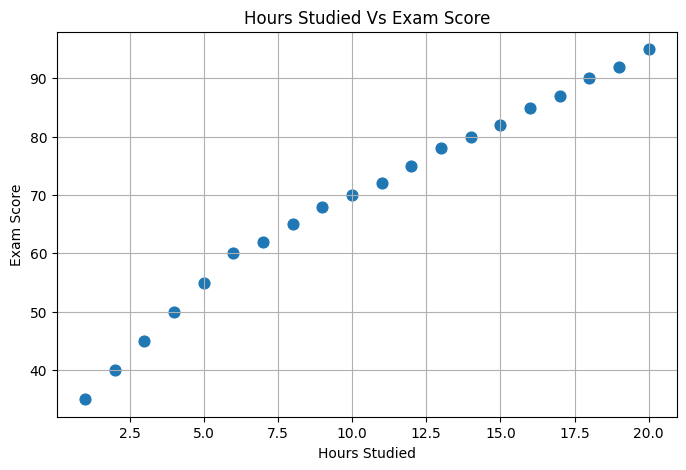

In [ ]:
# Scatter-plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y,s = 60)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied Vs Exam Score')
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 16
Testing Samples: 4


In [ ]:
# Scaling is particularly useful for Ridge and Lasso
# Tree-based models do not require scaling

scaler = StandardScaler()

X_train_Scaler = scaler.fit_transform(X_train)
X_test_Scaler = scaler.transform(X_test)

In [ ]:
# 1. SIMLE LINEAR REGRESSION
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test) # not scaled data

print("Intercept",linear_model.intercept_)
print("Slope:",linear_model.coef_[0])
print("Regression Equation:")
print("Score(y) = ",round(linear_model.intercept_,2), "+", round(linear_model.coef_[0],2),"x Hours")

Intercept 41.36223797315638
Slope: 2.741064696124265
Regression Equation:
Score(y) =  41.36 + 2.74 x Hours


In [ ]:
# 2. RIDGE REGRESSION
ridge_model = Ridge(alpha=1.0) # alpha increase, coeff decrease/normalize
ridge_model.fit(X_train_Scaler, y_train)
ridge_pred = ridge_model.predict(X_test_Scaler) # Scaled train data

print("RIDGE REGRESSION")
print("=" * 50)
print("Alpha:", ridge_model.alpha)
print("Coefficient:", round(ridge_model.coef_[0],2))
print("Intercept:", round(ridge_model.intercept_,2))

RIDGE REGRESSION
Alpha: 1.0
Coefficient: 13.13
Intercept: 71.0


In [ ]:
# LASSO REGRESSION
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_Scaler, y_train)
lasso_pred = lasso_model.predict(X_test_Scaler)

print("LASSO REGRESSION")
print("=" * 50)
print("Alpha:", lasso_model.alpha)
print("Coefficient:", round(lasso_model.coef_[0],2))
print("Intercept:", round(lasso_model.intercept_,2))

LASSO REGRESSION
Alpha: 1.0
Coefficient: 12.95
Intercept: 71.0


In [ ]:
# 4. DECISION TREE REGRESSION
tree_model = DecisionTreeRegressor(max_depth = 3, random_state = 42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("DECISION TREE REGRESSION")
print("=" * 50)
print("Maximum Depth:", tree_model.max_depth)
print("Number of Nodes:", tree_model.tree_.node_count)

DECISION TREE REGRESSION
Maximum Depth: 3
Number of Nodes: 15


In [ ]:
# 5. RANDOM FOREST
forest_model = RandomForestRegressor(n_estimators = 100, max_depth = 3, random_state = 42)
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

print("RANDOM FOREST REGRESSION")
print("=" * 50)
print("Number of Trees(Estimators):", forest_model.n_estimators)
print("Maximum Depth:", forest_model.max_depth)
print("Number of Nodes:", forest_model.n_estimators * forest_model.max_depth)

RANDOM FOREST REGRESSION
Number of Trees(Estimators): 100
Maximum Depth: 3
Number of Nodes: 300


In [ ]:
prediction = {
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'Decision Tree Regression': tree_pred,
    'Random Forest Regression': forest_pred
}

In [ ]:
results = []
for model_name,prediction in prediction.items():
    mae = mean_absolute_error(y_test,prediction)
    mse = mean_squared_error(y_test,prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,prediction)
    results.append([model_name,mse,rmse,mae,r2])

results = pd.DataFrame(results,columns = ['Model', 'MAE','MSE','RMSE','R2'])

In [ ]:
print("MODEL PERFORMANCE COMAPRISON")
print("=" * 70)
print(results.round(4).to_string(index=False))

MODEL PERFORMANCE COMAPRISON
                   Model     MAE    MSE   RMSE     R2
       Linear Regression 32.5639 5.7065 4.2171 0.9484
        Ridge Regression 45.7711 6.7654 5.0064 0.9275
        Lasso Regression 49.0953 7.0068 5.2795 0.9222
Decision Tree Regression 39.7500 6.3048 5.7500 0.9370
Random Forest Regression 57.7560 7.5997 6.0478 0.9085


In [ ]:
comparison = pd.DataFrame({
    'Hours': X_test['Hours'].values,
    'Actual Score': y_test,
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'Decision Tree Regression': tree_pred,
    'Random Forest Regression': forest_pred
})
comparison = comparison.sort_values( by='Hours')
print("ACTUAL VS PREDICTED SCORE")
print(comparison.round(2).to_string(index=False))

ACTUAL VS PREDICTED SCORE
 Hours  Actual Score  Linear Regression  Ridge Regression  Lasso Regression  Decision Tree Regression  Random Forest Regression
     1            35              44.10             45.69             46.03                      45.0                     47.77
     2            40              46.84             48.27             48.58                      45.0                     47.77
    16            85              85.22             84.38             84.20                      80.0                     82.56
    18            90              90.70             89.54             89.29                      87.0                     88.80


Text(0.5, 1.0, 'Model vs R2 Score')

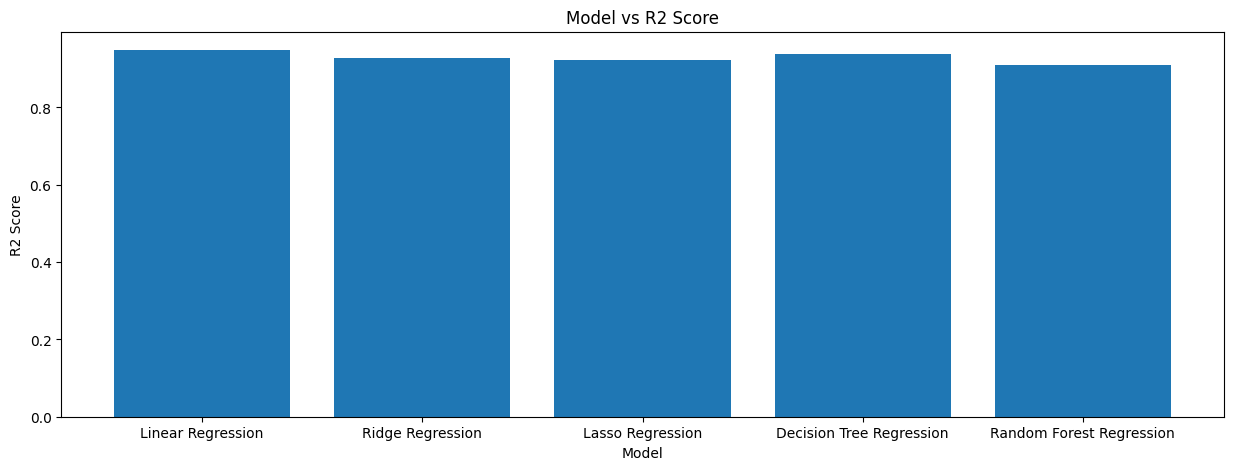

In [ ]:
# Bar Plot for r2 score
plt.figure(figsize=(15, 5))
plt.bar(results['Model'], results['R2'])
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('Model vs R2 Score')

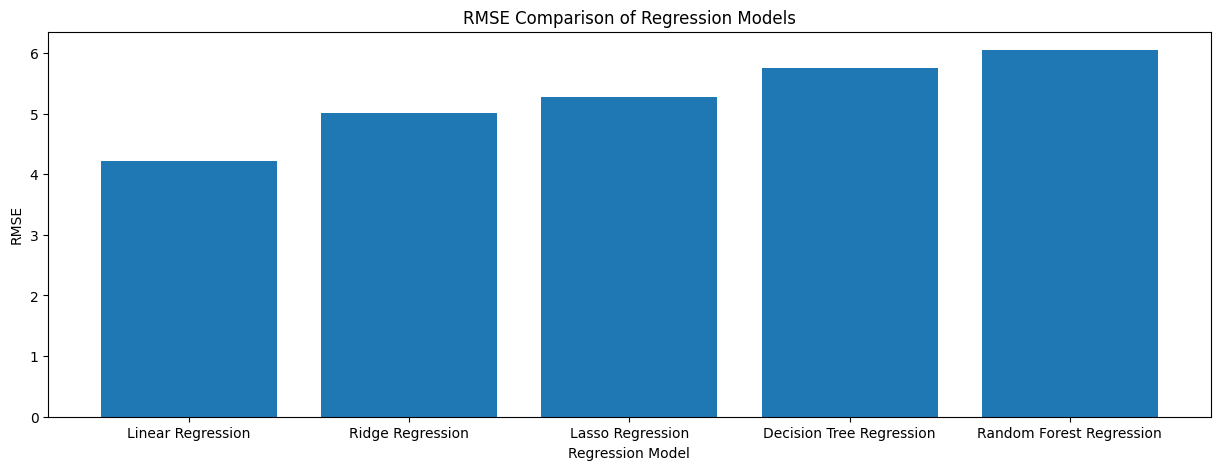

In [ ]:
# Bar Plot for rmse
plt.figure(figsize=(15, 5))
plt.bar(results['Model'], results['RMSE'])
plt.xlabel('Regression Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison of Regression Models')
plt.show()

In [ ]:
X_range = np.linspace(X['Hours'].min(),X['Hours'].max(),200).reshape(-1,1) # distribute
X_range

array([[ 1.        ],
       [ 1.09547739],
       [ 1.19095477],
       [ 1.28643216],
       [ 1.38190955],
       [ 1.47738693],
       [ 1.57286432],
       [ 1.66834171],
       [ 1.7638191 ],
       [ 1.85929648],
       [ 1.95477387],
       [ 2.05025126],
       [ 2.14572864],
       [ 2.24120603],
       [ 2.33668342],
       [ 2.4321608 ],
       [ 2.52763819],
       [ 2.62311558],
       [ 2.71859296],
       [ 2.81407035],
       [ 2.90954774],
       [ 3.00502513],
       [ 3.10050251],
       [ 3.1959799 ],
       [ 3.29145729],
       [ 3.38693467],
       [ 3.48241206],
       [ 3.57788945],
       [ 3.67336683],
       [ 3.76884422],
       [ 3.86432161],
       [ 3.95979899],
       [ 4.05527638],
       [ 4.15075377],
       [ 4.24623116],
       [ 4.34170854],
       [ 4.43718593],
       [ 4.53266332],
       [ 4.6281407 ],
       [ 4.72361809],
       [ 4.81909548],
       [ 4.91457286],
       [ 5.01005025],
       [ 5.10552764],
       [ 5.20100503],
       [ 5

In [ ]:
# PREDICTIONS FOR SMOOTH CURVES
linear_curve = linear_model.predict(X_range)
ridge_curve = ridge_model.predict((scaler.transform(X_range)))
lasso_curve = lasso_model.predict((scaler.transform(X_range)))
tree_curve = tree_model.predict(X_range)
forest_curve = forest_model.predict(X_range)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


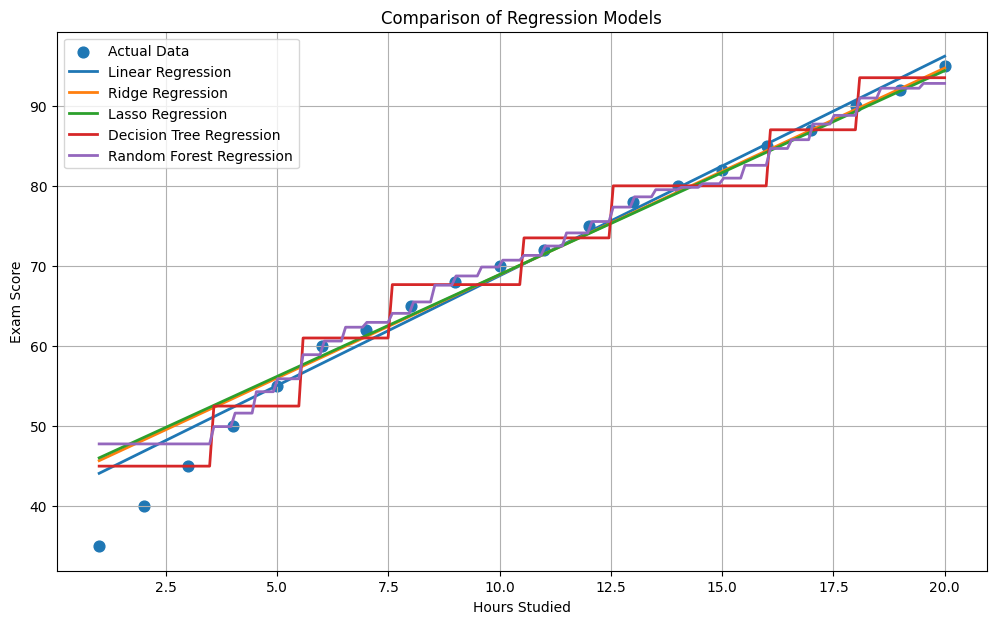

In [ ]:
# PLOT ALL REGRESSION MODELS
plt.figure(figsize=(12,7))
# Actual Data
plt.scatter(X, y, s = 60, label='Actual Data')
# Linear Regression
plt.plot(X_range,linear_curve,linewidth=2, label='Linear Regression')
# Ridge Regression
plt.plot(X_range,ridge_curve,linewidth=2, label='Ridge Regression')
# Lasso Regression
plt.plot(X_range,lasso_curve,linewidth=2, label='Lasso Regression')
# Decision Tree Regression
plt.plot(X_range,tree_curve,linewidth=2, label='Decision Tree Regression')
# Random Forest Regression
plt.plot(X_range,forest_curve,linewidth=2, label='Random Forest Regression')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Comparison of Regression Models')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
new_hours = [[12]]
new_linear = linear_model.predict(new_hours)[0]
new_ridge = ridge_model.predict(scaler.transform(new_hours))[0]
new_lasso = lasso_model.predict(scaler.transform(new_hours))[0]
new_tree = tree_model.predict(new_hours)[0]
new_forest = forest_model.predict(new_hours)[0]

prediction_result = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Decision Tree Regression', 'Random Forest Regression'],
    'Predicted Score': [new_linear, new_ridge, new_lasso, new_tree, new_forest]
})
print("PREDICTION FOR NEW STUDENT")
print("Hours Studied:", new_hours[0][0])
print(prediction_result.round(2).to_string(index=False))

PREDICTION FOR NEW STUDENT
Hours Studied: 12
                   Model  Predicted Score
       Linear Regression            74.26
        Ridge Regression            74.06
        Lasso Regression            74.02
Decision Tree Regression            73.50
Random Forest Regression            74.12


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Decision Tree Regression': tree_model,
    'Random Forest Regression': forest_model
}

In [ ]:
best_model_name = results_df.loc[results_df["R2"].idxmax(),"Model"]
best_model1 = models[best_model_name]
best_model1

LinearRegression()

In [ ]:
# Pickle File: stores the entire trained model(code)
import joblib

joblib.dump(best_model1,'best_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [ ]:
model = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')

In [ ]:
def predict_score(hours):
  sample_hours = np.array([hours])
  # sample_hours = scaler.transform(sample_hours) # use if model is lasso/ridge
  prediction = model.predict([sample_hours])
  return f"Predicted Score Based on Hours: {int(prediction[0])}"

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn = predict_score, # function
    inputs = [gr.Number(label="Enter Hours")],
    outputs="text",
    title="Score Prediction System Based on Hours",
    description="Enter the number of hours a student has studied and the model will predict their exam score."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c2dedf6935ede2597f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
